In [27]:
import numpy as np
import pandas as pd

! pip install requests

In [2]:
import requests


In [3]:
# importing the countries

url= 'https://api.worldbank.org/countries?format=json&per_page=300'

response= requests.get(url)
response.status_code

200

In [4]:
data= response.json()
print(data[0]) # metadata
print(len(data))
print(data[1]) # Actual data

{'page': 1, 'pages': 1, 'per_page': '300', 'total': 296}
2
[{'id': 'ABW', 'iso2Code': 'AW', 'name': 'Aruba', 'region': {'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Latin America & Caribbean '}, 'adminregion': {'id': '', 'iso2code': '', 'value': ''}, 'incomeLevel': {'id': 'HIC', 'iso2code': 'XD', 'value': 'High income'}, 'lendingType': {'id': 'LNX', 'iso2code': 'XX', 'value': 'Not classified'}, 'capitalCity': 'Oranjestad', 'longitude': '-70.0167', 'latitude': '12.5167'}, {'id': 'AFE', 'iso2Code': 'ZH', 'name': 'Africa Eastern and Southern', 'region': {'id': 'NA', 'iso2code': 'NA', 'value': 'Aggregates'}, 'adminregion': {'id': '', 'iso2code': '', 'value': ''}, 'incomeLevel': {'id': 'NA', 'iso2code': 'NA', 'value': 'Aggregates'}, 'lendingType': {'id': '', 'iso2code': '', 'value': 'Aggregates'}, 'capitalCity': '', 'longitude': '', 'latitude': ''}, {'id': 'AFG', 'iso2Code': 'AF', 'name': 'Afghanistan', 'region': {'id': 'MEA', 'iso2code': 'ZQ', 'value': 'Middle East, North Africa, Afghanistan &

In [5]:
countries= data[1]
countries= pd.DataFrame(countries)

In [6]:
countries.head()

,id,iso2Code,name,region,adminregion,incomeLevel,lendingType,capitalCity,longitude,latitude
0,ABW,AW,Aruba,"{'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Lati...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'HIC', 'iso2code': 'XD', 'value': 'High...","{'id': 'LNX', 'iso2code': 'XX', 'value': 'Not ...",Oranjestad,-70.0167,12.5167
1,AFE,ZH,Africa Eastern and Southern,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,
2,AFG,AF,Afghanistan,"{'id': 'MEA', 'iso2code': 'ZQ', 'value': 'Midd...","{'id': 'MNA', 'iso2code': 'XQ', 'value': 'Midd...","{'id': 'LIC', 'iso2code': 'XM', 'value': 'Low ...","{'id': 'IDX', 'iso2code': 'XI', 'value': 'IDA'}",Kabul,69.1761,34.5228
3,AFR,A9,Africa,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,
4,AFW,ZI,Africa Western and Central,"{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': ''}","{'id': 'NA', 'iso2code': 'NA', 'value': 'Aggre...","{'id': '', 'iso2code': '', 'value': 'Aggregates'}",,,


In [7]:
countries['region']= countries['region'].apply(lambda x: x['value'])

In [8]:
countries['incomeLevel']= countries['incomeLevel'].apply(lambda x: x['value'])

In [9]:
countries['lendingType']= countries['lendingType'].apply(lambda x: x['value'])

In [10]:
countries.drop(columns=['adminregion', 'capitalCity', 'lendingType'], inplace= True)

In [11]:
countries.rename(columns={'iso2Code': 'country_id'}, inplace= True)

In [12]:
countries

,id,country_id,name,region,incomeLevel,longitude,latitude
0,ABW,AW,Aruba,Latin America & Caribbean,High income,-70.0167,12.5167
1,AFE,ZH,Africa Eastern and Southern,Aggregates,Aggregates,,
2,AFG,AF,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income,69.1761,34.5228
3,AFR,A9,Africa,Aggregates,Aggregates,,
4,AFW,ZI,Africa Western and Central,Aggregates,Aggregates,,
...,...,...,...,...,...,...,...
291,XZN,A5,Sub-Saharan Africa excluding South Africa and ...,Aggregates,Aggregates,,
292,YEM,YE,"Yemen, Rep.","Middle East, North Africa, Afghanistan & Pakistan",Low income,44.2075,15.352
293,ZAF,ZA,South Africa,Sub-Saharan Africa,Upper middle income,28.1871,-25.746
294,ZMB,ZM,Zambia,Sub-Saharan Africa,Lower middle income,28.2937,-15.3982


In [13]:
base_url= 'https://api.worldbank.org/v2/indicators?format=json'
response= requests.get(base_url)
response.status_code

200

In [14]:
indicator= response.json()

In [15]:
print(indicator[0])

{'page': 1, 'pages': 587, 'per_page': '50', 'total': 29323}


In [16]:
pd.DataFrame(indicator[1])

,id,name,unit,source,sourceNote,sourceOrganization,topics
0,1.0.HCount.1.90usd,Poverty Headcount ($1.90 a day),,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty headcount index measures the propo...,LAC Equity Lab tabulations of SEDLAC (CEDLAS a...,"[{'id': '11', 'value': 'Poverty '}]"
1,1.0.HCount.2.5usd,Poverty Headcount ($2.50 a day),,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty headcount index measures the propo...,LAC Equity Lab tabulations of SEDLAC (CEDLAS a...,"[{'id': '11', 'value': 'Poverty '}]"
2,1.0.HCount.Mid10to50,Middle Class ($10-50 a day) Headcount,,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty headcount index measures the propo...,LAC Equity Lab tabulations of SEDLAC (CEDLAS a...,"[{'id': '11', 'value': 'Poverty '}]"
3,1.0.HCount.Ofcl,Official Moderate Poverty Rate-National,,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty headcount index measures the propo...,LAC Equity Lab tabulations of data from Nation...,"[{'id': '11', 'value': 'Poverty '}]"
4,1.0.HCount.Poor4uds,Poverty Headcount ($4 a day),,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty headcount index measures the propo...,LAC Equity Lab tabulations of SEDLAC (CEDLAS a...,"[{'id': '11', 'value': 'Poverty '}]"
5,1.0.HCount.Vul4to10,Vulnerable ($4-10 a day) Headcount,,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty headcount index measures the propo...,LAC Equity Lab tabulations of SEDLAC (CEDLAS a...,"[{'id': '11', 'value': 'Poverty '}]"
6,1.0.PGap.1.90usd,Poverty Gap ($1.90 a day),,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty gap captures the mean aggregate in...,LAC Equity Lab tabulations of SEDLAC (CEDLAS a...,"[{'id': '11', 'value': 'Poverty '}]"
7,1.0.PGap.2.5usd,Poverty Gap ($2.50 a day),,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty gap captures the mean aggregate in...,LAC Equity Lab tabulations of SEDLAC (CEDLAS a...,"[{'id': '11', 'value': 'Poverty '}]"
8,1.0.PGap.Poor4uds,Poverty Gap ($4 a day),,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty gap captures the mean aggregate in...,LAC Equity Lab tabulations of SEDLAC (CEDLAS a...,"[{'id': '11', 'value': 'Poverty '}]"
9,1.0.PSev.1.90usd,Poverty Severity ($1.90 a day),,"{'id': '37', 'value': 'LAC Equity Lab'}",The poverty severity index combines informatio...,LAC Equity Lab tabulations of SEDLAC (CEDLAS a...,"[{'id': '11', 'value': 'Poverty '}]"


In [17]:
import time

all_dfs= []

for i in range(1,587):
    url= f"https://api.worldbank.org/v2/indicators?format=json&per+page=500&page={i}"
    response= requests.get(url)
    if response.status_code==200:
        data= response.json()
        
        if len(data)<2:
            print(f'No data at page {i}')
            
        indicators=data[1]
        df= pd.DataFrame([{'id':item['id'], 'name': item['name']} for item in indicators])
        all_dfs.append(df)
        print(f'Page {i} : {len(df)} indicators collected')
    else:
        print(f'Failed to fetch page{i} status code {response.status_code}')
    time.sleep(0.3)


Page 1 : 50 indicators collected
Page 2 : 50 indicators collected
Page 3 : 50 indicators collected
Page 4 : 50 indicators collected
Page 5 : 50 indicators collected
Page 6 : 50 indicators collected
Page 7 : 50 indicators collected
Page 8 : 50 indicators collected
Page 9 : 50 indicators collected
Page 10 : 50 indicators collected
Page 11 : 50 indicators collected
Page 12 : 50 indicators collected
Page 13 : 50 indicators collected
Page 14 : 50 indicators collected
Page 15 : 50 indicators collected
Page 16 : 50 indicators collected
Page 17 : 50 indicators collected
Page 18 : 50 indicators collected
Page 19 : 50 indicators collected
Page 20 : 50 indicators collected
Page 21 : 50 indicators collected
Page 22 : 50 indicators collected
Page 23 : 50 indicators collected
Page 24 : 50 indicators collected
Page 25 : 50 indicators collected
Page 26 : 50 indicators collected
Page 27 : 50 indicators collected
Page 28 : 50 indicators collected
Page 29 : 50 indicators collected
Page 30 : 50 indicators

In [18]:
final_df= pd.concat(all_dfs, ignore_index= True)

In [19]:
final_df.to_csv('final_df.csv')

In [20]:
# extract value for indicators under the domain for each category

In [21]:
indicator_groups = {
    "economic_activity_growth": [
        "NY.GDP.MKTP.KD.ZG",  # GDP growth (annual %)
        "NY.GDP.PCAP.CD",    # GDP per capita (current US$)
    ],

    "labour_market_indicators": [
        "SL.UEM.TOTL.ZS",    # Unemployment, total
        "SL.UEM.1524.ZS",    # Unemployment youth total (ages 15-24)
        "SL.TLF.TOTL.IN",    # Labour force, total
    ],

    "trade_globalization": [
        "NE.EXP.GNFS.CD",    # Exports of goods and services (current US$)
        "NE.IMP.GNFS.CD",    # Imports of goods and services (current US$)
    ],

    "poverty_inequality": [
        "SI.POV.NAHC",       # Poverty headcount ratio at national poverty lines (% of population)
        "SI.POV.GINI",       # Gini index (measure of income inequality)
    ],

    "environmental_indicators": [
        "EG.FEC.RNEW.ZS",    # Renewable energy consumption (% of total final energy consumption)
        "AG.LND.FRST.ZS",    # Forest area (% of land area)
    ],

    "health_indicators": [
        "SP.DYN.LE00.IN",     # Life expectancy at birth
        "SP.DYN.IMRT.IN",    # Infant mortality rate
        "SH.H2O.BASW.ZS",    # Access to at least basic water services (% of population)
        "SH.XPD.CHEX.GD.ZS", # Current health expenditure (% of GDP)
        "SH.IMM.IDPT",       # Immunization, DPT (% of children ages 12–23 months)
        "SH.IMM.MEAS",       # Immunization, measles (% of children ages 12–23 months)
        "SH.MMR.RISK.ZS",    # Risk of maternal death
        "SH.DTH.COMM.ZS",    # Deaths from communicable diseases (% of total)
        "SH.TBS.INCD",       # Tuberculosis incidence (per 100,000 people)
        "SH.STA.BRTC.ZS",    # Births attended by skilled health staff (%)
        "SH.STA.MMRT",       # Maternal mortality ratio (modeled estimate, per 100,000 live births)
        "SP.POP.65UP.TO.ZS", # Population ages 65 and above (% of total population)
        "SH.HIV.INCD.ZS",    # HIV incidence rate (per 1,000 uninfected population ages 15–49)
    ],
    
    "technology_indicators": [
        "IT.NET.USER.ZS",    # Individuals using the Internet (% of population)
        "IT.CEL.SETS.P2",    # Mobile cellular subscriptions (per 100 people)
    ]}


In [22]:
for category,indicator in indicator_groups.items():
    print(category)
    print(indicator)

economic_activity_growth
['NY.GDP.MKTP.KD.ZG', 'NY.GDP.PCAP.CD']
labour_market_indicators
['SL.UEM.TOTL.ZS', 'SL.UEM.1524.ZS', 'SL.TLF.TOTL.IN']
trade_globalization
['NE.EXP.GNFS.CD', 'NE.IMP.GNFS.CD']
poverty_inequality
['SI.POV.NAHC', 'SI.POV.GINI']
environmental_indicators
['EG.FEC.RNEW.ZS', 'AG.LND.FRST.ZS']
health_indicators
['SP.DYN.LE00.IN', 'SP.DYN.IMRT.IN', 'SH.H2O.BASW.ZS', 'SH.XPD.CHEX.GD.ZS', 'SH.IMM.IDPT', 'SH.IMM.MEAS', 'SH.MMR.RISK.ZS', 'SH.DTH.COMM.ZS', 'SH.TBS.INCD', 'SH.STA.BRTC.ZS', 'SH.STA.MMRT', 'SP.POP.65UP.TO.ZS', 'SH.HIV.INCD.ZS']
technology_indicators
['IT.NET.USER.ZS', 'IT.CEL.SETS.P2']


In [23]:
base_url= "https://api.worldbank.org/countries/all/indicators/{}?format=json&per_page=1000&page={}"

In [24]:
import time
base_url= "https://api.worldbank.org/countries/all/indicators/{}?format=json&per_page=1000&page={}"

category_dataframes={}
for category, indicators in indicator_groups.items():
    print(f'Fetch information for category:  {category}')
    all_dfs_for_category =[]

    for indicator_code in indicators:
        print(f'Fetchin indicator: {indicator_code}')
        page=1
        
        while True:
            url= base_url.format(indicator_code, page)
            response= requests.get(url)
            if response.status_code!=200:
                print(f'No data for indicator {indicator_code} on page {page}')

            data= response.json()
            if len(data)<2:
                print(f'Failed at page {page}')
                break
                
            total_pages = data[0]['pages']
            record= data[1]
            
            df= pd.json_normalize(record)
            df=df[["country.id", "country.value", "indicator.id", 
                   "indicator.value","date","value"]].rename(columns={ "country.id":"country_id",
                                                                      "country.value":"country_value", "indicator.id":"indicator_id", 
                                                                      "indicator.value":"indicator_name","date": "year"})
            df= df[df["year"].astype(int)>2015]
            all_dfs_for_category.append(df)
            if page>=total_pages:
                break
            else:
                page+=1
                time.sleep(0.3)

    if all_dfs_for_category:
        combined_df= pd.concat(all_dfs_for_category, ignore_index=True)
        category_dataframes[category]=combined_df
        print(f'Total rows collected for {category}: {len(combined_df)}')
    else:
        print(f'No data collected for {category}')

print( 'Data fetching completed')


    

Fetch information for category:  economic_activity_growth
Fetchin indicator: NY.GDP.MKTP.KD.ZG
Fetchin indicator: NY.GDP.PCAP.CD
Total rows collected for economic_activity_growth: 4788
Fetch information for category:  labour_market_indicators
Fetchin indicator: SL.UEM.TOTL.ZS
Fetchin indicator: SL.UEM.1524.ZS
Fetchin indicator: SL.TLF.TOTL.IN
Total rows collected for labour_market_indicators: 7182
Fetch information for category:  trade_globalization
Fetchin indicator: NE.EXP.GNFS.CD
Fetchin indicator: NE.IMP.GNFS.CD
Total rows collected for trade_globalization: 4788
Fetch information for category:  poverty_inequality
Fetchin indicator: SI.POV.NAHC
Fetchin indicator: SI.POV.GINI


C:\Users\karis\AppData\Local\Temp\ipykernel_20276\1740569245.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_df= pd.concat(all_dfs_for_category, ignore_index=True)


Total rows collected for poverty_inequality: 4788
Fetch information for category:  environmental_indicators
Fetchin indicator: EG.FEC.RNEW.ZS
Fetchin indicator: AG.LND.FRST.ZS
Total rows collected for environmental_indicators: 4788
Fetch information for category:  health_indicators
Fetchin indicator: SP.DYN.LE00.IN
Fetchin indicator: SP.DYN.IMRT.IN
Fetchin indicator: SH.H2O.BASW.ZS
Fetchin indicator: SH.XPD.CHEX.GD.ZS
Fetchin indicator: SH.IMM.IDPT
Fetchin indicator: SH.IMM.MEAS
Fetchin indicator: SH.MMR.RISK.ZS
Fetchin indicator: SH.DTH.COMM.ZS
Fetchin indicator: SH.TBS.INCD
Fetchin indicator: SH.STA.BRTC.ZS
Fetchin indicator: SH.STA.MMRT
Fetchin indicator: SP.POP.65UP.TO.ZS
Fetchin indicator: SH.HIV.INCD.ZS
Total rows collected for health_indicators: 31122
Fetch information for category:  technology_indicators
Fetchin indicator: IT.NET.USER.ZS
Fetchin indicator: IT.CEL.SETS.P2
Total rows collected for technology_indicators: 4788
Data fetching completed


In [29]:
economic_activity= category_dataframes.get('economic_activity_growth', pd.DataFrame())
labour_market_jobs= category_dataframes.get('labour_market_indicators', pd.DataFrame())
trade_globalization= category_dataframes.get('trade_globalization', pd.DataFrame())
poverty_inequality= category_dataframes.get('poverty_inequality', pd.DataFrame())
environmental_indicators= category_dataframes.get('environmental_indicators', pd.DataFrame())
health_indicators= category_dataframes.get('health_indicators', pd.DataFrame())
technology_indicators= category_dataframes.get('technology_indicators', pd.DataFrame())




In [32]:
economic= pd.merge(economic_activity, countries, on= 'country_id', how='inner')
labour_market= pd.merge(labour_market_jobs, countries, on= 'country_id', how='inner')
trade= pd.merge(trade_globalization, countries, on= 'country_id', how='inner')
poverty= pd.merge(poverty_inequality, countries, on= 'country_id', how='inner')
environment= pd.merge(environmental_indicators, countries, on= 'country_id', how='inner')
health= pd.merge(health_indicators, countries, on= 'country_id', how='inner')
technology= pd.merge(technology_indicators, countries, on= 'country_id', how='inner')

In [34]:
economic.drop(columns=['indicator_id', 'name', 'id'], inplace= True )
labour_market.drop(columns=['indicator_id', 'name', 'id'], inplace= True )
trade.drop(columns=['indicator_id', 'name', 'id'], inplace= True )
poverty.drop(columns=['indicator_id', 'name', 'id'], inplace= True )
environment.drop(columns=['indicator_id', 'name', 'id'], inplace= True )
health.drop(columns=['indicator_id', 'name', 'id'], inplace= True )
technology.drop(columns=['indicator_id', 'name', 'id'], inplace= True )

In [36]:
economic.to_csv('economic.csv')
labour_market.to_csv('labour_market.csv')
trade.to_csv('trade.csv')
poverty.to_csv('poverty.csv')
environment.to_csv('environment.csv')
health.to_csv('health.csv')
technology.to_csv('technology.csv')


In [1]:
import pandas as pd
health= pd.read_csv('health.csv')

In [2]:
health.head()

,country_id,country_value,indicator_name,year,value,region,incomeLevel,longitude,latitude
0,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2024,NaN,Aggregates,Aggregates,NaN,NaN
1,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2023,65.146154,Aggregates,Aggregates,NaN,NaN
2,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2022,64.487020,Aggregates,Aggregates,NaN,NaN
3,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2021,62.979999,Aggregates,Aggregates,NaN,NaN
4,ZH,Africa Eastern and Southern,"Life expectancy at birth, total (years)",2020,63.766484,Aggregates,Aggregates,NaN,NaN


In [10]:
df_wide.head()

indicator_name      Births attended by skilled health staff (% of total)  \
country_value year                                                         
Afghanistan   2016                                                NaN      
              2017                                               53.4      
              2018                                               58.8      
              2019                                                NaN      
              2020                                               61.8      

indicator_name      Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)  \
country_value year                                                                                                          
Afghanistan   2016                                                NaN                                                       
              2017                                                NaN                                                       
              2018                                                NaN                                                       
              2019                                          32.930451                                                       
              2020                                                NaN                                                       

indicator_name      Current health expenditure (% of GDP)  \
country_value year                                          
Afghanistan   2016                              11.818590   
              2017                              12.620817   
              2018                              14.208419   
              2019                              14.831320   
              2020                              15.533614   

indicator_name      Immunization, DPT (% of children ages 12-23 months)  \
country_value year                                                        
Afghanistan   2016                                               66.0     
              2017                                               64.0     
              2018                                               68.0     
              2019                                               65.0     
              2020                                               61.0     

indicator_name      Immunization, measles (% of children ages 12-23 months)  \
country_value year                                                            
Afghanistan   2016                                               64.0         
              2017                                               64.0         
              2018                                               66.0         
              2019                                               57.0         
              2020                                               57.0         

indicator_name      Incidence of HIV, ages 15-49 (per 1,000 uninfected population ages 15-49)  \
country_value year                                                                              
Afghanistan   2016                                                0.1                           
              2017                                                0.1                           
              2018                                                0.1                           
              2019                                                0.1                           
              2020                                                0.1                           

indicator_name      Incidence of tuberculosis (per 100,000 people)  \
country_value year                                                   
Afghanistan   2016                                           204.0   
              2017                                           209.0   
              2018                                           212.0   
              2019                                   

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

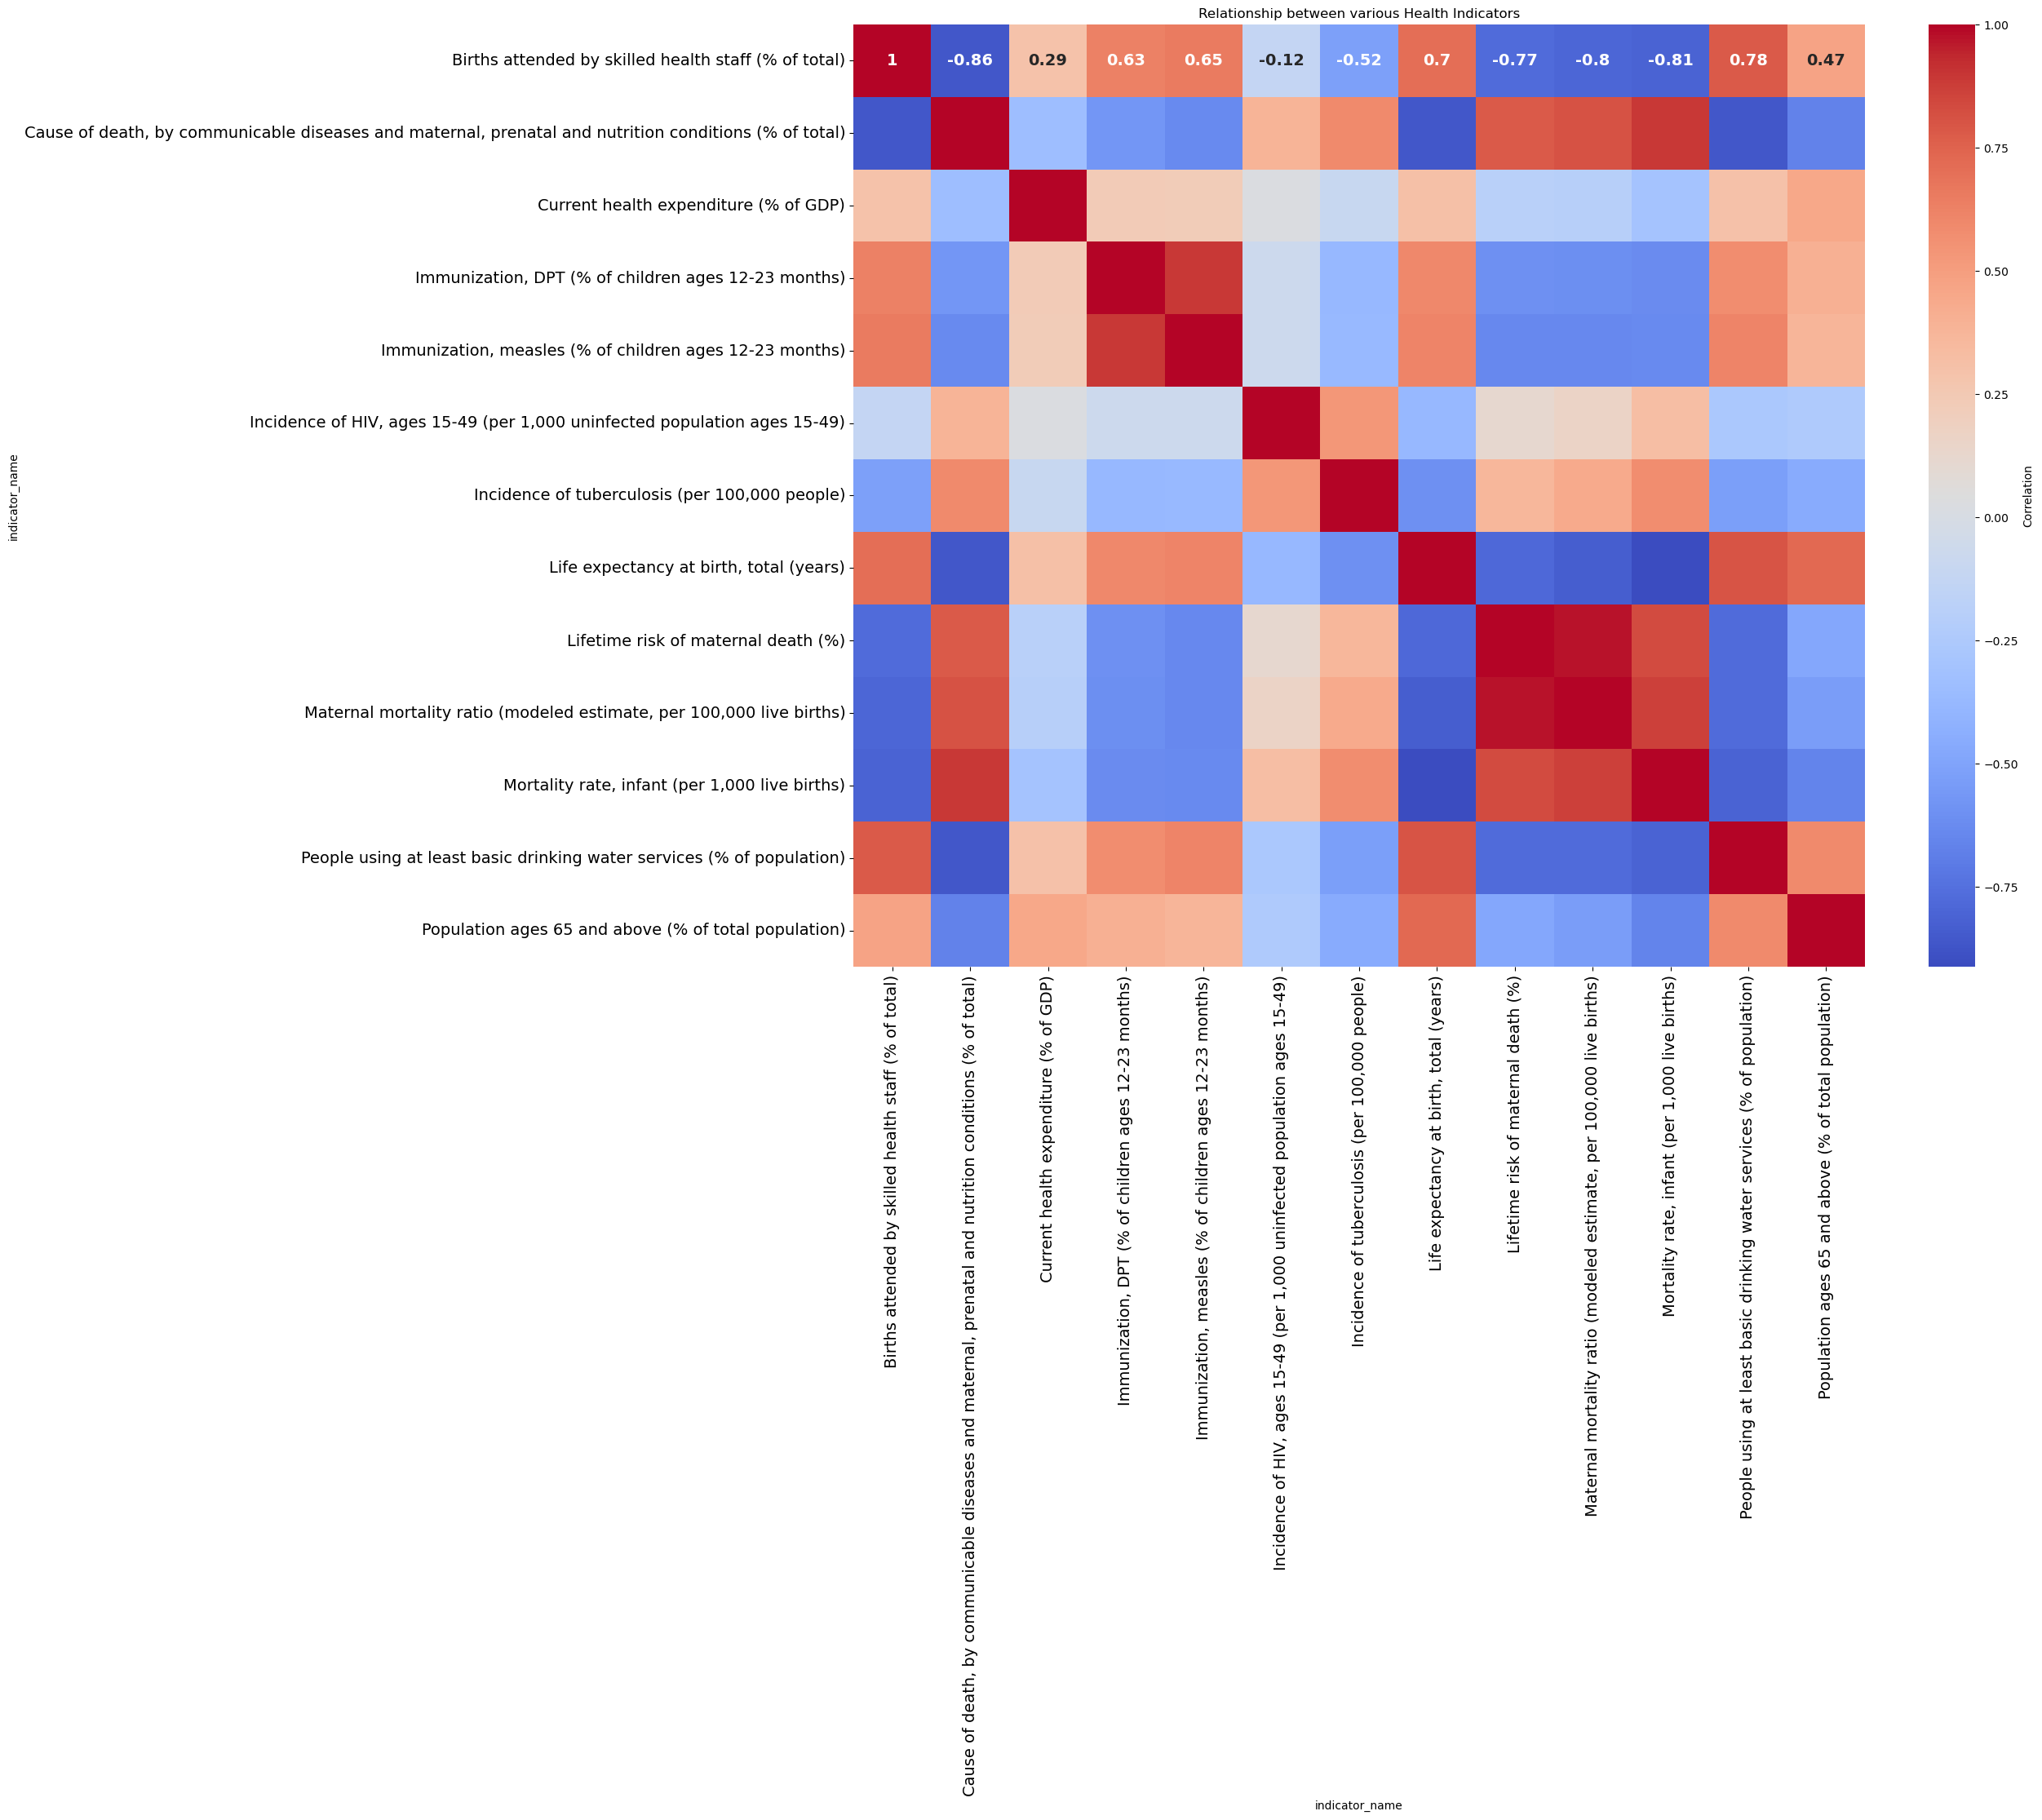

In [25]:
df_wide= health.pivot_table(index= ['country_value', 'year'], columns= 'indicator_name', values='value')
corr= df_wide.corr()


plt.figure(figsize=(20,15), facecolor='none')

ax= sns.heatmap(corr, 
                annot= True,
            cmap='coolwarm',
            cbar_kws= {'label':'Correlation'},
            annot_kws= {'fontsize':14, 'fontweight': 'bold'}
)
plt.title('Relationship between various Health Indicators')
ax.tick_params(axis='x', labelsize= 14)
ax.tick_params(axis='y', labelsize= 14)

plt.show()



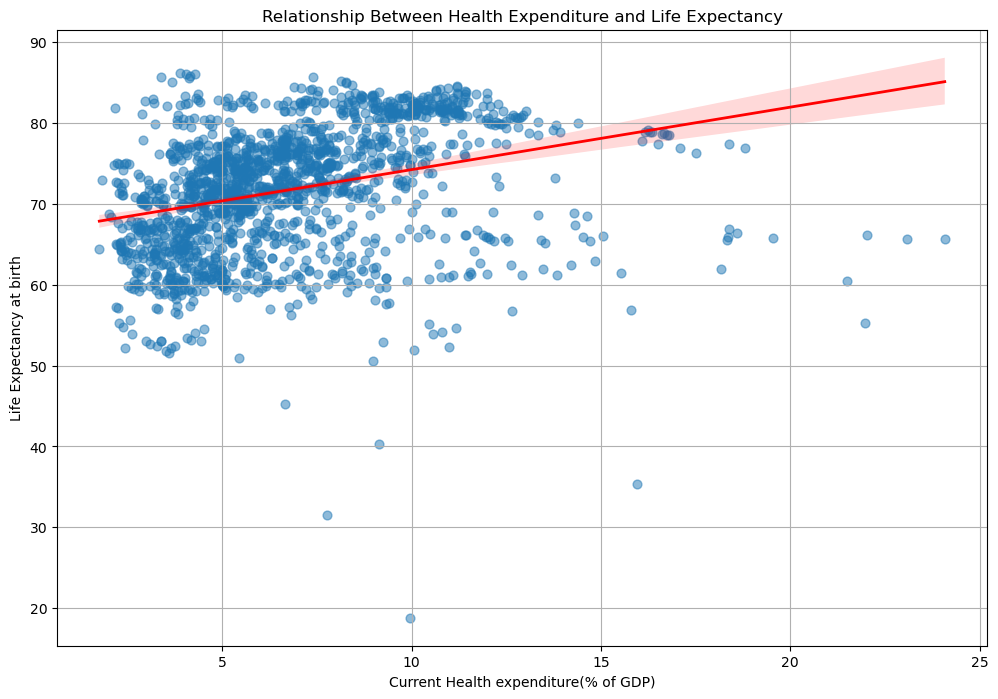

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

df_pivot=health.pivot(index=['country_value', 'year'], columns='indicator_name', values='value')

plt.figure(figsize=(12,8),facecolor='none')

ax= sns.regplot(data=df_pivot, 
                x='Current health expenditure (% of GDP)',
                y= 'Life expectancy at birth, total (years)',
                scatter_kws= {'alpha': 0.5, 's':40},
                line_kws= {'color': 'red', 'lw':2}
               )
plt.title('Relationship Between Health Expenditure and Life Expectancy')
plt.xlabel('Current Health expenditure(% of GDP)')
plt.ylabel('Life Expectancy at birth')
plt.grid(True)
plt.show()

